In [47]:
import os
from tqdm import tqdm
import pandas as pd
import seaborn as sns
from services.PoseScoringService import PoseScoringService

In [51]:
base_path = "./temp/dataset/handstand/"
video_paths = os.listdir(base_path)
pose_names = ["starting", "swing", "landing"]
df = pd.DataFrame(columns=pose_names+["frame"])

pose_scoring_service = PoseScoringService()
for video_path in tqdm(video_paths[8:9]):
    full_path = os.path.join(base_path, video_path)
    
    poses_scores, _ = pose_scoring_service.get_poses_from_video(full_path, "handstand")
    for frame_index, score in enumerate(poses_scores):
        new_row = []
        for pose_name in pose_names:
            new_row.append(score.get(pose_name, {"score": 0})["score"])
        
        new_row.append(frame_index)
        df.loc[len(df)] = new_row
    

  0%|          | 0/1 [00:00<?, ?it/s]I0000 00:00:1767965623.225797   59681 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1767965623.231930   69357 gl_context.cc:369] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1767965623.438913   69346 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1767965624.458021   69348 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████| 1/1 [00:10<00:00, 10.11s/it]


In [52]:
df.head()

,starting,swing,landing,frame
0,0.334236,0.208595,0.586139,0.0
1,0.334935,0.211124,0.589071,1.0
2,0.334978,0.211553,0.590447,2.0
3,0.337408,0.208540,0.582360,3.0
4,0.341497,0.205619,0.569191,4.0


<Axes: xlabel='frame'>

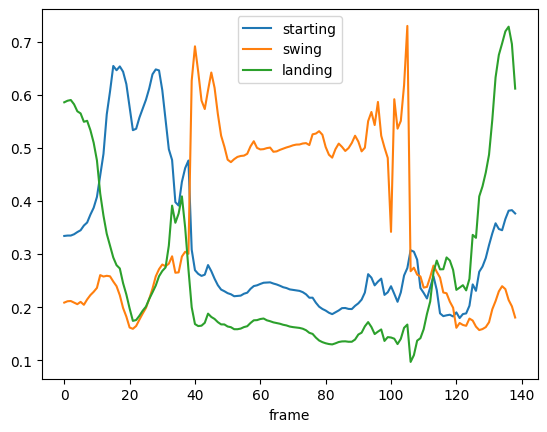

In [53]:
df_mean = df.groupby("frame")[["starting", "swing", "landing"]].mean()

df_mean.plot()